# Lesson 16: Modeling a Fast Reactor Unit Cell

The mean-free path of fast neutrons is often substantially larger than the dimensions of an individual fuel pin cell.  Consequently, the spatial variation of the neutron flux within a single fuel pin cell can be ignored, and the multiplication factor for an infinite array of fast-reactor unit cells is given by  Eq. (4.8) of FNRP: 
$$
  k_{\infty} =  \frac{V_f \nu \bar{\Sigma}_f^f}
    {V_f \bar{\Sigma}_a^f + V_c \bar{\Sigma}_a^c + V_{st} \nu \bar{\Sigma}_a^{st}} \, ,
  \tag{FNRP 4.8}
$$

where the bars on the $\Sigma$'s indicate spectrum-weighted, effective cross sections for the fuel (f), structural (st), and coolant (c) regions.

In this tutorial, we'll compute the multiplication factor and spectrum for a representative sodium-cooled, fast reactor unit cell by applying the homogeneous medium approximation. Some data and dimensions used come from [this report](https://www.oecd-nea.org/science/wprs/sfr-taskforce/WPRS-AEN-SFR-Cores-V1.2.pdf).


Specifically, we assume a pin cell with the following dimensions:

  - fuel radius $r_f = 0.4742$ cm
  - cladding radius $r_c = 0.5419$ cm
  - pin pitch $P = 1.1897$ cm
  
These correspond to values listed in Table 4 of the report.
  
For the fuel, we'll assume UO$_2$ ($\rho = 10.5$ g/cm$^3$) enriched to 15\%. We'll further assume that the cladding is an oxide dispersion strengthened (ODS) steel ($\rho = 7.13$ g/cm$^3$) and that the coolant is pure sodium ($\rho = 0.837$ g/cm$^3$).

In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model = openmc.Model()

First, let's define the base materials.

In [3]:
uo2 = openmc.Material(name="uo2")
uo2.add_element('U', 1.0, enrichment=15.0)
uo2.add_element('O', 2.0)
uo2.set_density('g/cc', 10.5)

coolant =  openmc.Material(name="coolant") 
coolant.add_nuclide("Na23", 1)
coolant.set_density('g/cm3', 0.837)

# From Table 13 of the document.  These are number densities.  OpenMC will renormalize.
cladding_composition = {
            "C":  3.5740E-04, "O":  3.9924E-04, "Ti": 5.3824E-04, "Cr": 1.7753E-02,
            "Fe": 5.3872E-02, "Ni": 3.6588E-04, "Mn": 2.3441E-04, "P":  2.7718E-05,
            "Al": 9.1482E-03, "Co": 2.1852E-04, "Cu": 1.0135E-04, "Y":  2.6616E-04}
cladding = openmc.Material(name="cladding")
for i in cladding_composition:
    cladding.add_element(i, cladding_composition[i], 'ao')
cladding.set_density('g/cm3', 7.13)

/home/robertsj/opt/miniforge3/envs/openmc/lib/python3.13/site-packages/openmc/material.py:1059: UserWarning: A uranium enrichment of 15.0 was given for Material ID="1". OpenMC assumes the U234/U235 mass ratio is constant at 0.008, which is only valid at low enrichments. Consider setting the isotopic composition manually for enrichments over 5%.
  warnings.warn(msg)


Now, let's define the geometrical dimensions and compute volume fractions.  We're ignoring the gas gap between the fuel and inner cladding surface.

In [4]:
P = 1.1897               # pitch
s = P/np.sqrt(3)         # side length
A = 3*np.sqrt(3)/2*s**2  # area of hexagon

r_f = 0.4742 # fuel radius
r_c = 0.5419 # cladding outer radius 

V_f  = np.pi*r_f**2             # fuel volume
V_st = np.pi*(r_c**2 - r_f**2)  # structure volume
V_c  = A - V_f - V_st           # coolant volume

With these volumes, we can produce a volume-weighted material:

In [5]:
mixture = openmc.Material.mix_materials([uo2, cladding, coolant], [V_f/A, V_st/A, V_c/A], "vo")

As we've done before, we'll use a reflected sphere of unit volume to house our homogeneous medium:

In [6]:
sphere = openmc.Sphere(r=(3/(4*np.pi))**(1/3), boundary_type="reflective") 

In [7]:
mixture_cell = openmc.Cell()
mixture_cell.region = -sphere
mixture_cell.fill = mixture

root_universe = openmc.Universe(cells=(mixture_cell,))
model.geometry.root_universe = root_universe

Unlike our slowing-down problems, in this model, we'll be solving the $k$-eigenvalue problem. 

In [8]:
settings = openmc.Settings()
settings.run_mode = "eigenvalue" 

Under the hood, OpenMC uses an algorithm that looks a _lot_ like [power iteration](https://robertsj.github.io/ne415_notes/lectures/L16_OneEigenpairFromIteration.html#Power-iteration), which, for $\mathbf{Ax}=\lambda \mathbf{x}$ finds the largest eigenvalue $\lambda^*$ and its eigenvector $\mathbf{x}^*$ using the iteration

$$
  \mathbf{x}^{(i+1)} = \mathbf{A} \mathbf{x}^{(i)} / ||\mathbf{x}^{(i)}||_2
$$

starting from some initial guess $\mathbf{x}^{(0)}$.  Once $\mathbf{x}^*$ is known, then $\lambda^*$ comes from the Rayleigh quotient $\lambda = (\mathbf{x}^T \mathbf{Ax}) / (\mathbf{x}^T \mathbf{x})$.

Though we don't have explicit matrices here, we _do_ need an initial guess for the distribution of neutrons.  Here, that's a point source of 2 MeV neutrons born isotropically at the origin:

In [9]:
space_distn = openmc.stats.Point((0, 0, 0))
energy_distn = openmc.stats.Discrete([2e6], [1.0]) 
source = openmc.IndependentSource(space=space_distn, energy=energy_distn)
settings.source = source

The rest of the setup is similar to our other models:

In [10]:
settings.batches = 100
settings.particles = 1000
model.settings = settings

energies = np.logspace(np.log10(1.0), np.log10(1e7), 1000)
e_filter = openmc.EnergyFilter(energies)
tally = openmc.Tally()
tally.filters = [e_filter]
tally.scores = ['flux']
model.tallies = [tally]

In [11]:
sp_path = model.run(output=True)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

       72/1    1.27581    1.27322 +/- 0.00358
       73/1    1.24556    1.27284 +/- 0.00355
       74/1    1.36402    1.27408 +/- 0.00371
       75/1    1.24278    1.27366 +/- 0.00369
       76/1    1.23810    1.27319 +/- 0.00367
       77/1    1.25448    1.27295 +/- 0.00363
       78/1    1.22069    1.27228 +/- 0.00364
       79/1    1.29423    1.27256 +/- 0.00361
       80/1    1.28317    1.27269 +/- 0.00357
       81/1    1.24720    1.27237 +/- 0.00354
       82/1    1.36302    1.27348 +/- 0.00366
       83/1    1.29439    1.27373 +/- 0.00363
       84/1    1.26666    1.27365 +/- 0.00358
       85/1    1.24434    1.27330 +/- 0.00356
       86/1    1.33331    1.27400 +/- 0.00359
       87/1    1.26986    1.27395 +/- 0.00354
       88/1    1.33048    1.27459 +/- 0.00356
       89/1    1.17888    1.27352 +/- 0.00368
       90/1    1.31472    1.27398 +/- 0.00367
       91/1    1.20565    1.27323 +/- 0.00371
       92/1    1.22241    1.27267 +/- 0.00371
       93/1    1.24337    1.27236 

In [12]:
with openmc.StatePoint(sp_path) as sp:
    t = sp.tallies[tally.id]
    flux_mean = t.mean.ravel()
    flux_unc = t.std_dev.ravel()

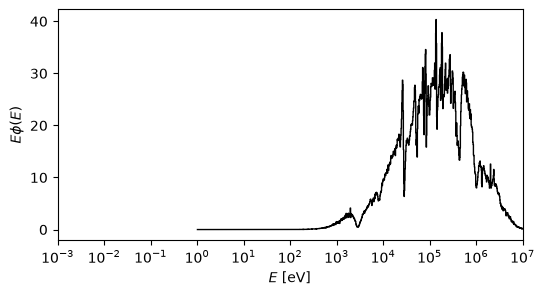

In [13]:
E = energies[1:]
dE = np.diff(energies)

plt.figure(figsize=(6,3))
plt.step(E, E*flux_mean/dE, 
         where='post', color='k', lw=1, label="simulation")
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r'$E$ [eV]')
plt.ylabel(r'$E \phi(E)$');
plt.xlim(1e-0, 1e7)
plt.xticks(np.logspace(-3, 7, 11));

To understand at least some of the features of this spectrum, it helps to look at the cross sections of Na-23 and Fe-56, two major non-fuel components in the model:

In [14]:
import os
data_path = os.environ.get("OPENMC_CROSS_SECTIONS").replace("cross_sections.xml", "neutron/")

na23 = openmc.data.IncidentNeutron.from_hdf5(data_path+"Na23.h5")
fe56 = openmc.data.IncidentNeutron.from_hdf5(data_path+"Fe56.h5")

σ_γ_na23 = na23.reactions[102].xs["294K"]
σ_s_na23 = na23.reactions[2].xs["294K"]
σ_γ_fe56 = fe56.reactions[102].xs["294K"]
σ_s_fe56 = fe56.reactions[2].xs["294K"]

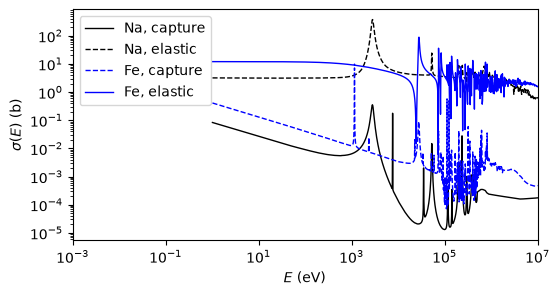

In [15]:
plt.figure(figsize=(6,3))
plt.loglog(E, σ_γ_na23(E), 'k',
           E, σ_s_na23(E), 'k--',
           E, σ_γ_fe56(E), 'b--',
           E, σ_s_fe56(E), 'b-', lw=1)
plt.legend(["Na, capture", "Na, elastic", "Fe, capture", "Fe, elastic"])
plt.ylabel(r"$\sigma(E)$ (b)")
plt.xlabel(r"$E$ (eV)")
plt.xlim(1e-3, 1e7);